In [ ]:
# Name: DVN Surya Kiran
# Roll No: CH.SC.U4CSE24116
# Exercise 2 - Weather Activity Decision Tree

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sn

In [ ]:
data = {
    'Weather': ['Sunny','Sunny','Rainy','Rainy','Sunny',
                'Rainy','Sunny','Rainy','Sunny','Rainy',
                'Sunny','Sunny','Rainy','Rainy','Sunny',
                'Rainy','Sunny','Rainy','Sunny','Rainy'],
    'GoOut':   [1, 1, 0, 0, 1,
                0, 1, 0, 1, 0,
                1, 1, 0, 0, 1,
                0, 1, 0, 1, 0]
}
df = pd.DataFrame(data)
df['Weather'] = df['Weather'].map({'Sunny': 1, 'Rainy': 0})
print(df)

    Weather  GoOut
0         1      1
1         1      1
2         0      0
3         0      0
4         1      1
5         0      0
6         1      1
7         0      0
8         1      1
9         0      0
10        1      1
11        1      1
12        0      0
13        0      0
14        1      1
15        0      0
16        1      1
17        0      0
18        1      1
19        0      0


In [ ]:
print(df.isnull().sum())
print(df.shape)

Weather    0
GoOut      0
dtype: int64
(20, 2)


In [ ]:
print(f"Go out when Sunny: {df[df['Weather']==1]['GoOut'].mean():.0%}")
print(f"Stay in when Rainy: {df[df['Weather']==0]['GoOut'].mean():.0%}")

Go out when Sunny: 100%
Stay in when Rainy: 0%


In [ ]:
x = df[['Weather']]
y = df['GoOut']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)

(16, 1) (4, 1)


In [ ]:
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("Predicted:", y_pred)
print("Actual:   ", y_test.values)

Predicted: [1 0 0 1]
Actual:    [1 0 0 1]


In [ ]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Accuracy %:", int(metrics.accuracy_score(y_test, y_pred)*100), '%')
print("\nClassification Report:\n", metrics.classification_report(y_test, y_pred))

Confusion Matrix:
 [[2 0]
 [0 2]]
Accuracy: 1.0
Accuracy %: 100 %

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [2]:
import seaborn as sn
sn.heatmap(conf_mat, annot=True, fmt='d')
plt.title('Confusion Matrix - Weather Activity')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

NameError: name 'conf_mat' is not defined

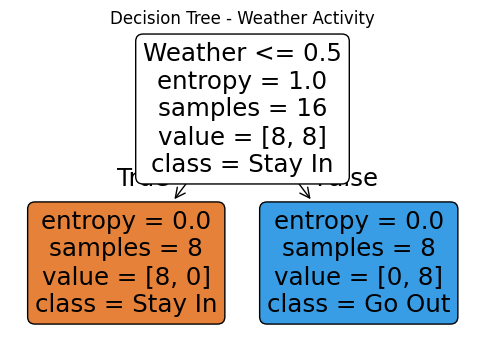

In [ ]:
plt.figure(figsize=(6, 4))
plot_tree(model, feature_names=['Weather'],
          class_names=['Stay In', 'Go Out'], filled=True, rounded=True)
plt.title('Decision Tree - Weather Activity')
plt.show()

In [ ]:
print("Observation: Weather is the only and root node.")
print("Sunny (1) → Go Out | Rainy (0) → Stay In")
print("Model achieves perfect classification on this dataset.")

Observation: Weather is the only and root node.
Sunny (1) → Go Out | Rainy (0) → Stay In
Model achieves perfect classification on this dataset.
